In [25]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

In [26]:
model_path = "../models/best_yolo8s_ball-detection.pt"
model = YOLO(model_path)

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

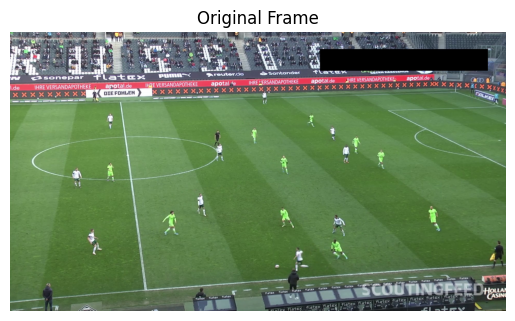

In [27]:
video_path = "../input_video/08fd33_4.mp4"

cap = cv2.VideoCapture(video_path)

frame_number = 30
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

ret, frame = cap.read()
cap.release()

if not ret:
    raise Exception("Gagal membaca frame dari video")

# Convert BGR → RGB (biar benar warnanya di matplotlib)
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.imshow(frame_rgb)
plt.title("Original Frame")
plt.axis("off")

In [28]:
results = model(frame_rgb, imgsz=1280)


0: 736x1280 1 ball, 691.6ms
Speed: 16.0ms preprocess, 691.6ms inference, 9.6ms postprocess per image at shape (1, 3, 736, 1280)


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

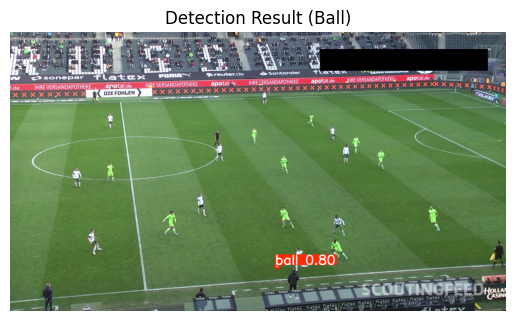

In [29]:
# Plot hasil langsung dari YOLO
annotated_frame = results[0].plot()

plt.imshow(annotated_frame)
plt.title("Detection Result (Ball)")
plt.axis("off")

In [30]:
for box in results[0].boxes:
    print("Confidence:", float(box.conf))
    print("Class:", int(box.cls))
    print("BBox:", box.xyxy.tolist())
    print("------")

Confidence: 0.8021883368492126
Class: 0
BBox: [[1026.2567138671875, 901.2335815429688, 1042.3377685546875, 914.0879516601562]]
------
